# Random vs UCB Stochastic Approximation — Binary MNIST

Compare `StochasticApproximation` (pure random search) against `StochasticApproximationUCBDynamic` (UCB over an adaptive binary partition) on `ReLUNet`s trained as binary MNIST classifiers (e.g. digits 1 vs 7).

Pipeline per architecture:
1. Train the network as a binary MNIST classifier on `DIGITS`.
2. Choose UCB's `partition_step` from `PARTITION_GRID` by the mean final value over `TUNE_SEEDS` (UCB only; these seeds are not used afterwards).
3. Run both methods across `N_SEEDS` repeats with the full `COMPARE_ITERS` budget — no early stop, no ground-truth reference. UCB seeds are shifted by 1000, so the two methods draw independent random streams.
4. Plot mean ± std convergence bands vs iterations and vs wall-clock time.

Domain: `[0, 1]^784` (matches MNIST pixel range). `c_vector = [1, -1]` projects onto the difference of the two class logits.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from relu_nets import ReLUNet
from hyperbox import Hyperbox
from experiments import runners
import neural_nets.data_loaders as data_loaders
import neural_nets.train as train

## Config — edit this cell

Each entry in `ARCHITECTURES` must start with `784` (MNIST input dim) and end with `2` (binary output).

In [2]:
INPUT_DIM     = 784
OUTPUT_DIM    = 2
DIGITS        = [1, 7]   # binary classification target
DATASET_DIR   = '../datasets'   # MNIST raw files live at LipSSA/datasets/MNIST/raw/

ARCHITECTURES = [
    # [INPUT_DIM, 4,           OUTPUT_DIM],
    # [INPUT_DIM, 16, 16,      OUTPUT_DIM],
    [INPUT_DIM, 32, 32,      OUTPUT_DIM],
    [INPUT_DIM, 64, 64, 64,  OUTPUT_DIM],
    [INPUT_DIM, 32, 32, 32, 32, OUTPUT_DIM],
]

PRIMAL_NORM   = 'linf'

TRAIN_EPOCHS  = 5
TRAIN_LR      = 1e-3
TRAIN_BATCH   = 64
TRAIN_SEED    = 0

COMPARE_ITERS = 500_000
N_SEEDS       = 5
SEEDS         = list(range(N_SEEDS))
TUNE_SEEDS    = list(range(100, 100 + N_SEEDS))

UCB_C          = 5
PARTITION_GRID = [2, 1.5]

## Helpers

Both methods run through `experiments.runners.run_method`, i.e. the solvers of `other_methods` unchanged. Best-so-far curves are rebuilt from the improvement history each solver records (`[iteration, seconds, value]` at every new maximum).

In [3]:
def train_mnist_network(arch, digits, epochs, lr, batch_size, seed=0, dataset_dir='../datasets'):
    torch.manual_seed(seed); np.random.seed(seed)
    net = ReLUNet(arch)
    mnist_train = data_loaders.load_mnist_data('train', digits=digits, batch_size=batch_size,
                                               shuffle=True, dataset_dir=dataset_dir)
    mnist_val   = data_loaders.load_mnist_data('val',   digits=digits, batch_size=batch_size,
                                               shuffle=True, dataset_dir=dataset_dir)
    train_params = train.TrainParameters(
        mnist_train, mnist_val, epochs,
        test_after_epoch=1,
        optimizer=torch.optim.Adam(net.parameters(), lr=lr),
    )
    train.training_loop(net, train_params)
    return net


def best_so_far(history, column, points):
    """Running maximum at each of `points`, from an improvement history
    [[iteration, seconds, value], ...]; column 0 reads `points` as iterations, 1 as seconds."""
    if not history:
        return np.zeros(len(points))
    h = np.asarray(history, dtype=float)
    idx = np.searchsorted(h[:, column], points, side='right') - 1
    return np.where(idx >= 0, h[np.maximum(idx, 0), 2], 0.0)


def band(records, column, points):
    v = np.stack([best_so_far(r['history'], column, points) for r in records])
    return v.mean(axis=0), v.std(axis=0)

## Run the experiment

In [4]:
domain   = Hyperbox.build_unit_hypercube(INPUT_DIM)
c_vector = torch.tensor([1.0, -1.0])

results, partition = {}, {}
for arch in ARCHITECTURES:
    assert arch[0] == INPUT_DIM and arch[-1] == OUTPUT_DIM, \
        f'Architecture must start with {INPUT_DIM} and end with {OUTPUT_DIM}: got {arch}'
    print(f'=== {arch} ===')
    net = train_mnist_network(arch, DIGITS, TRAIN_EPOCHS, TRAIN_LR, TRAIN_BATCH,
                              seed=TRAIN_SEED, dataset_dir=DATASET_DIR)

    tune = {tm: np.mean([runners.run_method('ucb', net, c_vector, domain, COMPARE_ITERS, s,
                                            primal_norm=PRIMAL_NORM, c=UCB_C, partition_step=tm)['value']
                         for s in TUNE_SEEDS])
            for tm in PARTITION_GRID}
    tm = partition[tuple(arch)] = max(tune, key=tune.get)
    print('  tuning: ' + ', '.join(f'partition_step {k}: {v:.4f}' for k, v in tune.items())
          + f'  ->  {tm}')

    runs = {'rand': [], 'ucb': []}
    for seed in SEEDS:
        rand = runners.run_method('uniform', net, c_vector, domain, COMPARE_ITERS, seed,
                                  primal_norm=PRIMAL_NORM)
        ucb = runners.run_method('ucb', net, c_vector, domain, COMPARE_ITERS, seed + 1000,
                                 primal_norm=PRIMAL_NORM, c=UCB_C, partition_step=tm)
        runs['rand'].append(rand)
        runs['ucb'].append(ucb)
        print(f"  seed {seed}: rand={rand['value']:.4f} ({rand['compute_time']:.2f}s)  "
              f"ucb={ucb['value']:.4f} ({ucb['compute_time']:.2f}s)")
    results[tuple(arch)] = runs

=== [784, 32, 32, 2] ===
Epoch 00 | Accuracy: 99.55
Epoch 01 | Accuracy: 99.60
Epoch 02 | Accuracy: 99.69
Epoch 03 | Accuracy: 99.75
Epoch 04 | Accuracy: 99.78
Epoch 05 | Accuracy: 99.80
  tuning: partition_step 2: 314.7088, partition_step 1.5: 314.7088  ->  2
  seed 0: rand=314.7088 (37.48s)  ucb=314.7088 (70.45s)
  seed 1: rand=314.7088 (37.44s)  ucb=314.7088 (75.24s)
  seed 2: rand=314.7088 (37.52s)  ucb=314.7088 (74.94s)
  seed 3: rand=298.9506 (39.31s)  ucb=314.7088 (73.57s)
  seed 4: rand=314.7088 (37.75s)  ucb=314.7088 (75.11s)
=== [784, 64, 64, 64, 2] ===
Epoch 00 | Accuracy: 99.61
Epoch 01 | Accuracy: 99.03
Epoch 02 | Accuracy: 99.55
Epoch 03 | Accuracy: 99.70
Epoch 04 | Accuracy: 99.81
Epoch 05 | Accuracy: 99.75
  tuning: partition_step 2: 309.5476, partition_step 1.5: 307.4708  ->  2
  seed 0: rand=256.5062 (44.56s)  ucb=258.3896 (80.01s)
  seed 1: rand=275.9274 (44.17s)  ucb=252.3713 (80.49s)
  seed 2: rand=236.8676 (44.22s)  ucb=268.2350 (80.65s)
  seed 3: rand=236.8676 (4

## Convergence — mean ± std vs iterations and vs time

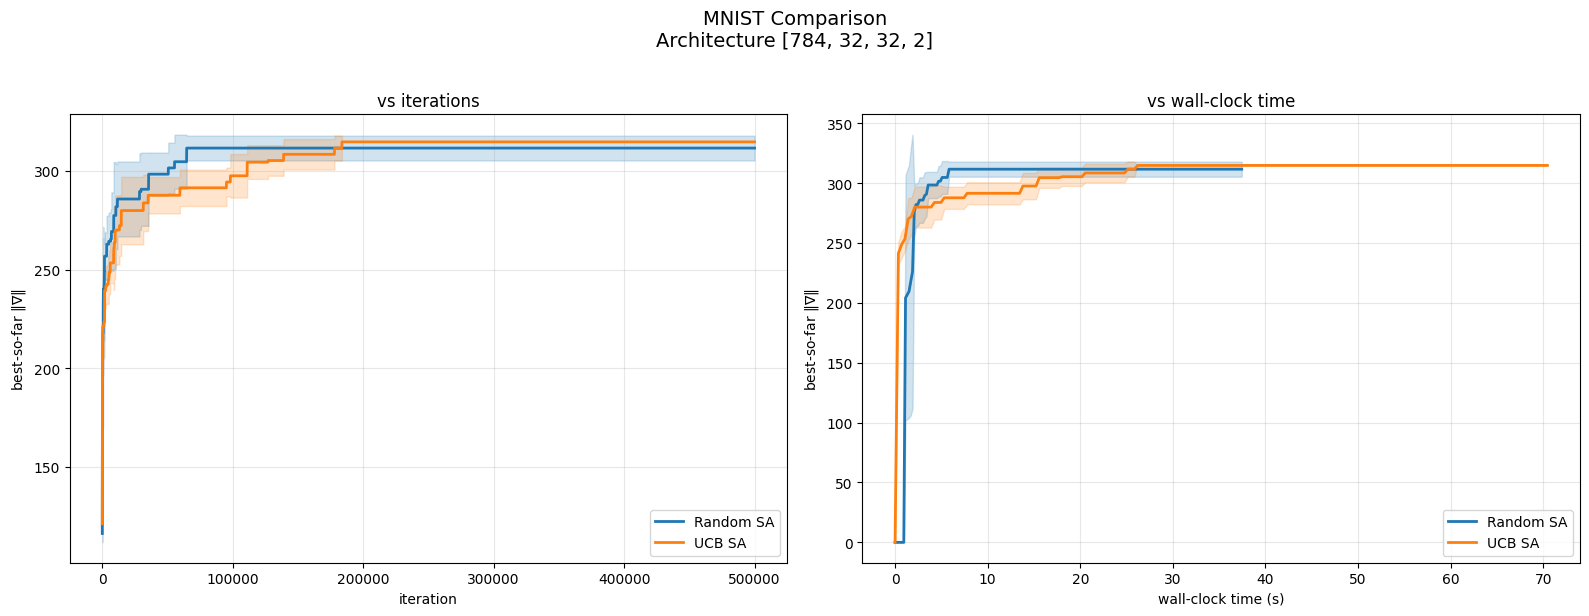

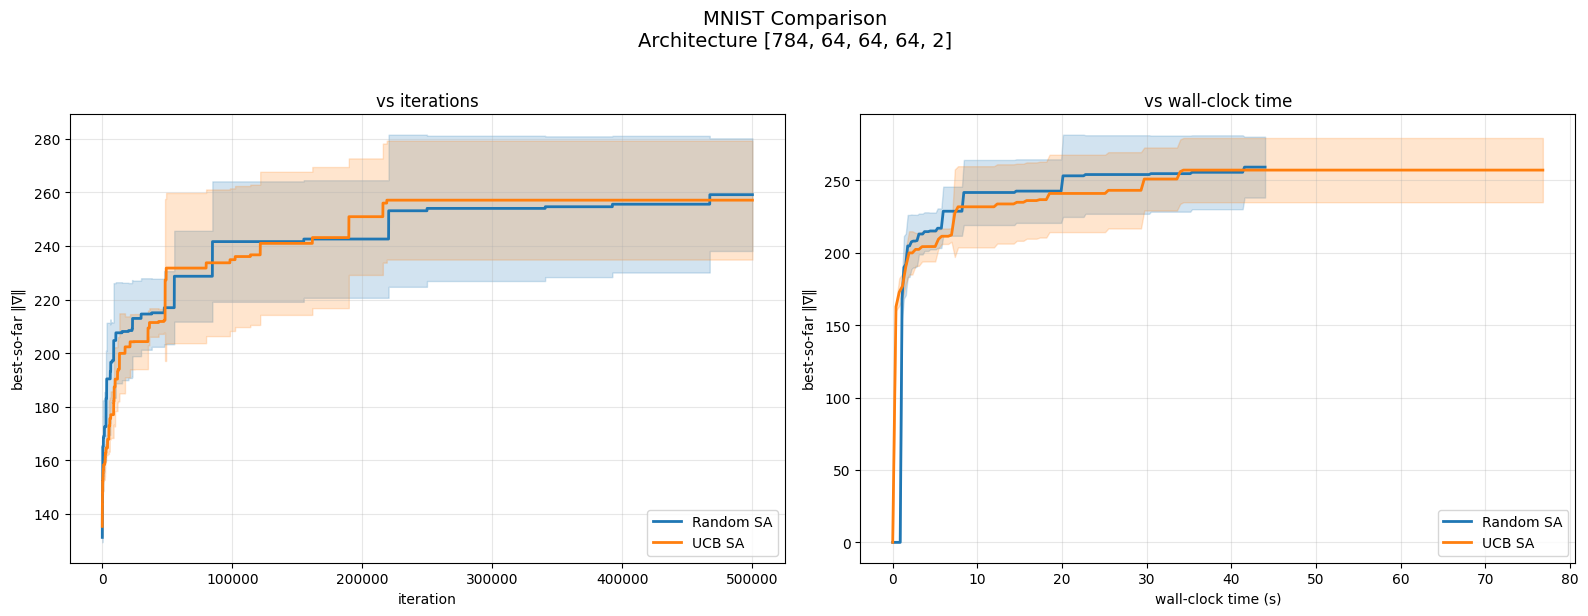

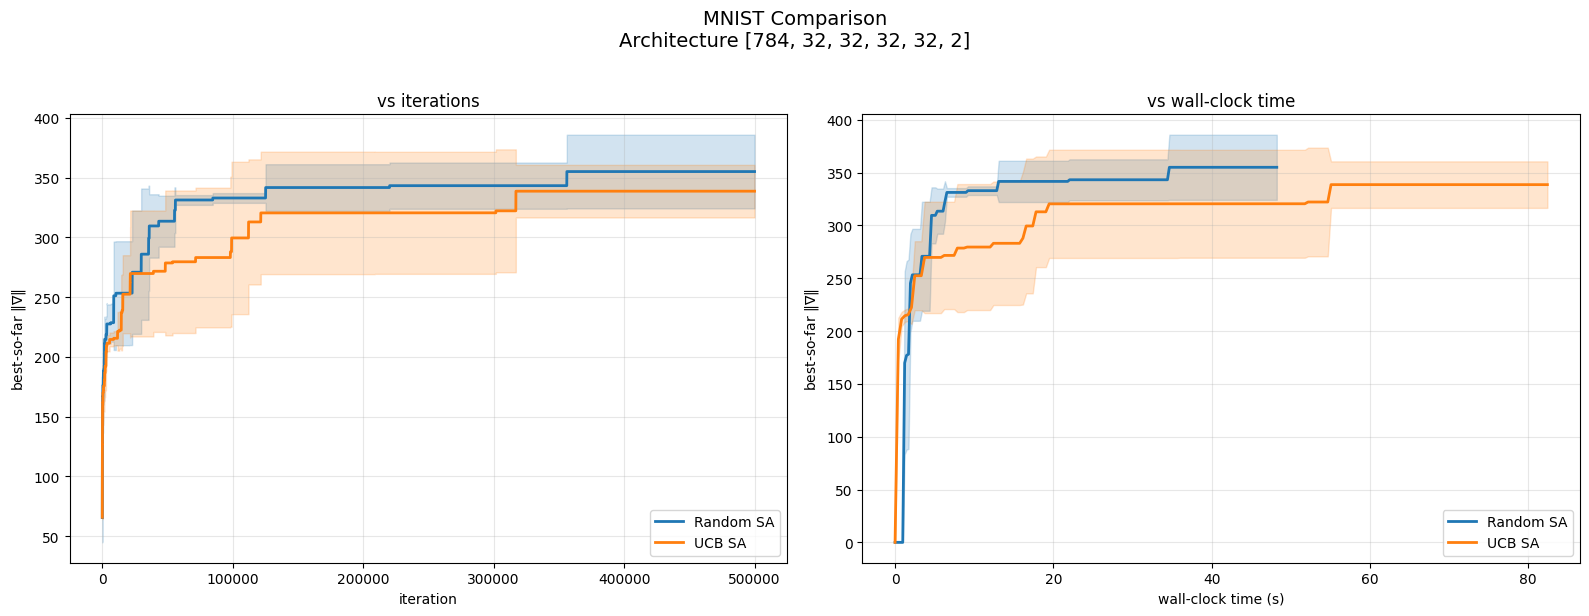

In [5]:
iters = np.arange(1, COMPARE_ITERS + 1)

for arch in ARCHITECTURES:
    runs = results[tuple(arch)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'MNIST Comparison\nArchitecture {arch}', fontsize=14, y=1.02)

    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        grid = np.linspace(0.0, min(r['compute_time'] for r in runs[key]), 200)
        for ax, column, points in [(axes[0], 0, iters), (axes[1], 1, grid)]:
            m, s = band(runs[key], column, points)
            ax.plot(points, m, label=label, color=color, linewidth=2)
            ax.fill_between(points, m - s, m + s, color=color, alpha=0.2)

    for ax, xlabel, title in [(axes[0], 'iteration', 'vs iterations'),
                              (axes[1], 'wall-clock time (s)', 'vs wall-clock time')]:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(r'best-so-far $\|\nabla\|$')
        ax.set_title(title)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Summary table

In [6]:
def fmt_meanstd(arr, unit='', precision=4):
    return f"{arr.mean():.{precision}f} ± {arr.std():.{precision}f}{unit}"


header = (f"{'arch':<28} {'method':>14} "
          f"{'final value':>22} {'total time':>20}")
print(header); print('-' * len(header))

for arch in ARCHITECTURES:
    runs = results[tuple(arch)]
    for method in ['rand', 'ucb']:
        finals = np.array([r['value'] for r in runs[method]])
        times  = np.array([r['compute_time'] for r in runs[method]])
        label = 'random' if method == 'rand' else f'ucb (t_m={partition[tuple(arch)]})'
        prefix_arch = str(arch) if method == 'rand' else ''
        print(f"{prefix_arch:<28} {label:>14} "
              f"{fmt_meanstd(finals, '', 4):>22} "
              f"{fmt_meanstd(times, ' s', 2):>20}")

arch                                 method            final value           total time
---------------------------------------------------------------------------------------
[784, 32, 32, 2]                     random      311.5571 ± 6.3033       37.90 ± 0.71 s
                                ucb (t_m=2)      314.7088 ± 0.0000       73.86 ± 1.81 s
[784, 64, 64, 64, 2]                 random     259.1614 ± 21.0287       44.28 ± 0.21 s
                                ucb (t_m=2)     257.1140 ± 22.1831       79.75 ± 1.51 s
[784, 32, 32, 32, 32, 2]             random     355.0857 ± 30.8449       49.31 ± 0.99 s
                                ucb (t_m=2)     338.6680 ± 22.0273       84.79 ± 1.29 s
